In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(12,5)
print("Libraries imported successfully")

Libraries imported successfully


In [2]:
#loading the excel file into python
df = pd.read_excel("Dataset for Data Analytics.xlsx")
#displaying the first 5 rows of the dataset
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
# checking the shape of the dataset
df.shape

(1200, 14)

In [4]:
# checking the data types of the columns
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [5]:
# checking for missing values in the dataset
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
# fill missing CouponCode with "NO COUPON"
df["CouponCode"] = df["CouponCode"].fillna("NO COUPON")

In [7]:
# verify no ,missing values in CouponCode
df["CouponCode"].isnull().sum()

np.int64(0)

In [8]:
# descriptive statistics of the dataset with number columns
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [9]:
# the descriptive stat of the total price
print("Average Order Value:", df['TotalPrice'].mean().round(2))
print("Median Order Value:", df['TotalPrice'].median().round(2))
print("Minimum Order Value:", df['TotalPrice'].min().round(2))
print("Maximum Order Value:", df['TotalPrice'].max().round(2))

Average Order Value: 1053.97
Median Order Value: 823.62
Minimum Order Value: 11.39
Maximum Order Value: 3456.4


In [10]:
# identifying outliers using the IQR method
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower_boundary:",lower_bound.round(2))
print("Upper_boundary:",upper_bound.round(2))
#find actual outliers
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print("Number of outliers:", outliers.shape[0])

Lower_boundary: -1341.41
Upper_boundary: 3330.41
Number of outliers: 8


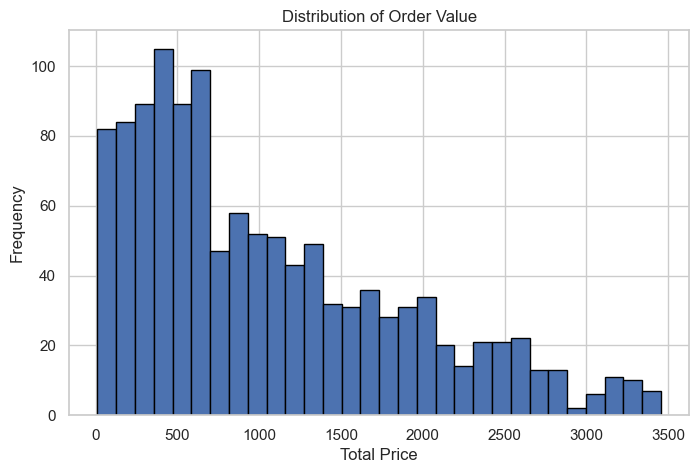

In [11]:
#telling the story with chart, distribution of total price
plt.figure(figsize=(8,5))
plt.hist(df['TotalPrice'], bins=30, edgecolor='black')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.title('Distribution of Order Value')
plt.show()

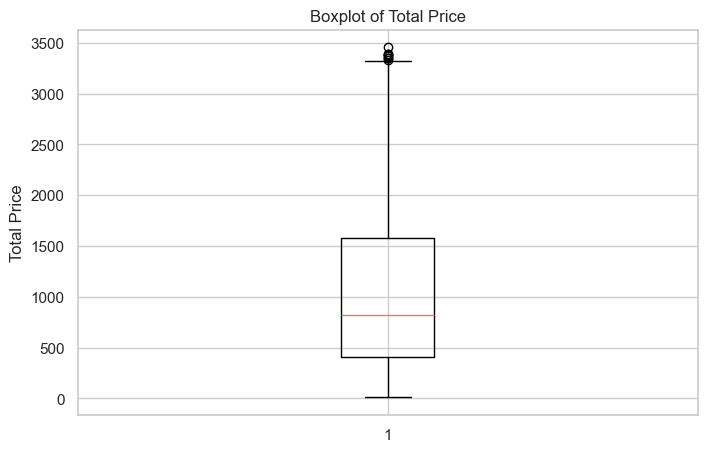

In [12]:
# boxplot to visualize outliers in total price
plt.figure(figsize=(8,5))
plt.boxplot(df['TotalPrice'])
plt.ylabel('Total Price')
plt.title('Boxplot of Total Price')
plt.show()

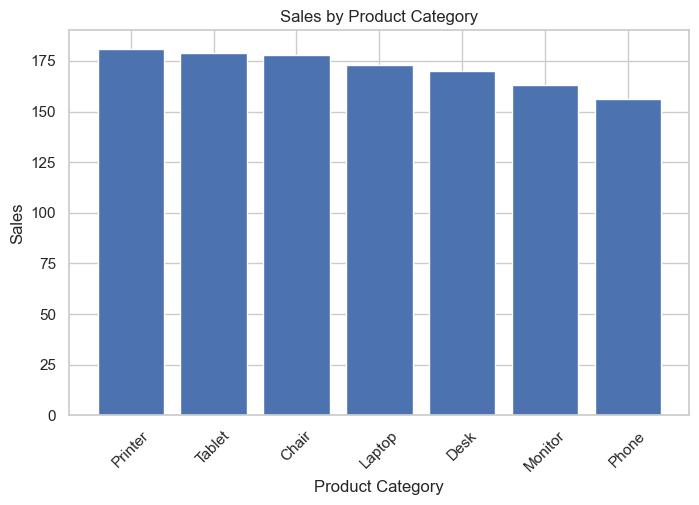

In [13]:
#Chart of product category which sales the most 
category_counts = df['Product'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.title('Sales by Product Category')
plt.xticks(rotation=45)
plt.show()


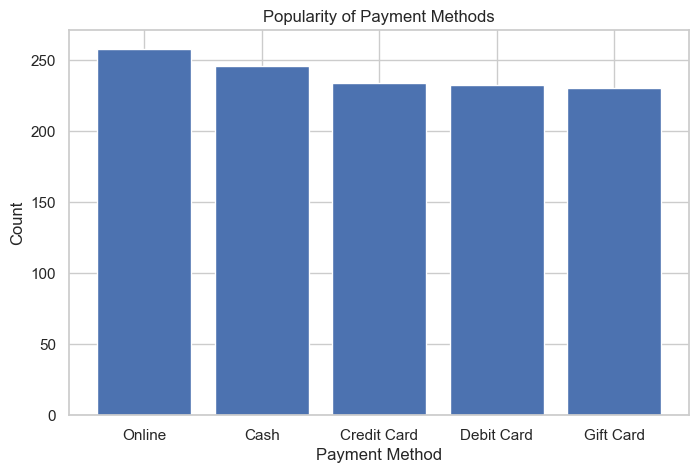

In [14]:
#Chart which payment method is more popular
payment_counts = df['PaymentMethod'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(payment_counts.index, payment_counts.values)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Popularity of Payment Methods')
plt.show()

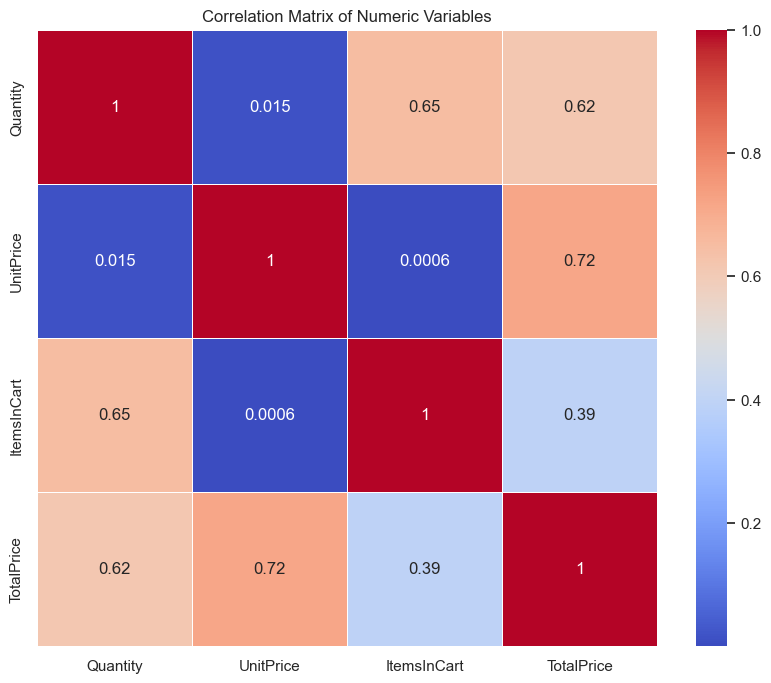

In [15]:
#  Chart of Correlation Analysis of total price with other numeric variables
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()